<a href="https://colab.research.google.com/github/tirthpatel618/dream-takehome/blob/main/Tirth_Patel_Dream_Takehome_Waterloo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

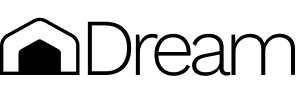
# **Dream Technologies Take-Home Challenge**

**At Dream, we’re building AI tools to make home design faster, cheaper, more enjoyable, and more democratized.** We'd like you to help us with a critical component: making interior layouts not just look good, but work. That means connecting rooms in a logical and usable way. We want you to build an algorithm that places doors between rooms in a house, just like an architect might when turning a layout into a livable space.

---

## The Problem
We've given you three example floorplans in JSON format. Each one defines the house boundary and a set of rooms with labeled functions (e.g. "bedroom", "kitchen"). Your task is to write an algorithm that places doors between rooms; choosing where and how rooms connect, and ensuring the house is traversable and coherent. You’ll implement your solution right here in Colab, and your code should produce door placement output for each sample input. We've given you a rendering utility so you can visualize your results using MatplotLib.

We will test your notebook on three different floorplans than the ones provided, so your algorithm should generalize to new layouts.

---

## The Data

Each floorplan is structured as a JSON object and includes:

`dimensions` *The width and height of the floorplan in feet.*

`exteriorWalls { x, y }` *A list of wall segments, each defined by a start and end point and a thickness.*

`rooms` *A list of rooms. Each of which has:*

`id` *Unique string identifier*

`name` *Display Name(e.g.“Primary Bedroom ”)*

`type` *Room function ( e.g . “bedroom” , “kitchen”)*

`walls` *A list of wall segments defining the room boundary*

Your algorithm will need to determine where rooms share walls and place door(s) appropriately. Room geometry is defined via 2D coordinates in feet; rooms that share wall segments are candidates for connections.

---

## Extra Considerations

While not required, for completeness, your algorithm can also consider:
* Only connect rooms where it makes functional sense
* Include door swing direction (e.g., left-hand vs. right-hand, swing outward vs. inward)
* Use open archways instead of doors for certain room pair
* Avoid unnecessary doors (e.g., bathrooms with three or more doors)

---

## Getting Started

1.  **Work in this colab notebook:** All your solutions, code, and analysis should be done in this notebook
2.  **Add Comments & Explanations:** Please document your thought process, code choices, and any assumptions you make.
3.  **Run All Cells:** Before you submit, ensure all your code runs correctly from top to bottom.
    * Go to `Runtime > Run all`. This helps us verify your solution.


This challenge is designed to be completed directly in Google Colab, and should only take an hour or two. Feel free to use AI coding tools if you'd like.

In [1]:
# Sample data
floorplan_1 = {
    "id": "1",
    "name": "One Bedroom Apartment",
    "dimensions": {
        "width": 50,  # feet
        "height": 30,  # feet
    },
    "exteriorWalls": [
        {"start": {"x": 0, "y": 0}, "end": {"x": 50, "y": 0}, "thickness": 0.5},
        {"start": {"x": 50, "y": 0}, "end": {"x": 50, "y": 30}, "thickness": 0.5},
        {"start": {"x": 50, "y": 30}, "end": {"x": 0, "y": 30}, "thickness": 0.5},
        {"start": {"x": 0, "y": 30}, "end": {"x": 0, "y": 0}, "thickness": 0.5},
    ],
    "rooms": [
        {
            "id": "kitchen",
            "name": "Kitchen",
            "type": "kitchen",
            "walls": [
                {"start": {"x": 0, "y": 30}, "end": {"x": 20, "y": 30}, "thickness": 0.3},
                {"start": {"x": 20, "y": 30}, "end": {"x": 20, "y": 20}, "thickness": 0.3},
                {"start": {"x": 20, "y": 20}, "end": {"x": 0, "y": 20}, "thickness": 0.3},
                {"start": {"x": 0, "y": 20}, "end": {"x": 0, "y": 30}, "thickness": 0.3},
            ],
        },
        {
            "id": "living",
            "name": "Living",
            "type": "living",
            "walls": [
                {"start": {"x": 20, "y": 30}, "end": {"x": 40, "y": 30}, "thickness": 0.3},
                {"start": {"x": 40, "y": 30}, "end": {"x": 40, "y": 20}, "thickness": 0.3},
                {"start": {"x": 40, "y": 20}, "end": {"x": 20, "y": 20}, "thickness": 0.3},
                {"start": {"x": 20, "y": 20}, "end": {"x": 20, "y": 30}, "thickness": 0.3},
            ],
        },
        {
            "id": "bathroom_1",
            "name": "Bathroom 1",
            "type": "bathroom",
            "walls": [
                {"start": {"x": 20, "y": 20}, "end": {"x": 30, "y": 20}, "thickness": 0.3},
                {"start": {"x": 30, "y": 20}, "end": {"x": 30, "y": 10}, "thickness": 0.3},
                {"start": {"x": 30, "y": 10}, "end": {"x": 20, "y": 10}, "thickness": 0.3},
                {"start": {"x": 20, "y": 10}, "end": {"x": 20, "y": 20}, "thickness": 0.3},
            ],
        },
        {
            "id": "bedroom",
            "name": "Bedroom",
            "type": "bedroom",
            "walls": [
                {"start": {"x": 30, "y": 20}, "end": {"x": 50, "y": 20}, "thickness": 0.3},
                {"start": {"x": 50, "y": 20}, "end": {"x": 50, "y": 10}, "thickness": 0.3},
                {"start": {"x": 50, "y": 10}, "end": {"x": 30, "y": 10}, "thickness": 0.3},
                {"start": {"x": 30, "y": 10}, "end": {"x": 30, "y": 20}, "thickness": 0.3},
            ],
        },
        {
            "id": "bathroom_2",
            "name": "Bathroom 2",
            "type": "bathroom",
            "walls": [
                {"start": {"x": 40, "y": 30}, "end": {"x": 50, "y": 30}, "thickness": 0.3},
                {"start": {"x": 50, "y": 30}, "end": {"x": 50, "y": 20}, "thickness": 0.3},
                {"start": {"x": 50, "y": 20}, "end": {"x": 40, "y": 20}, "thickness": 0.3},
                {"start": {"x": 40, "y": 20}, "end": {"x": 40, "y": 30}, "thickness": 0.3},
            ],
        },
    ],
}
floorplan_3 = {
    "id": "3",
    "name": "Two Bedroom Apartment",
    "dimensions": {
        "width": 40,  # feet
        "height": 30,  # feet
    },
    "exteriorWalls": [
        {"start": {"x": 0, "y": 0}, "end": {"x": 40, "y": 0}, "thickness": 0.5},
        {"start": {"x": 40, "y": 0}, "end": {"x": 40, "y": 30}, "thickness": 0.5},
        {"start": {"x": 40, "y": 30}, "end": {"x": 0, "y": 30}, "thickness": 0.5},
        {"start": {"x": 0, "y": 30}, "end": {"x": 0, "y": 0}, "thickness": 0.5},
    ],
    "rooms": [
        {
            "id": "bedroom_1",
            "name": "Bedroom 1",
            "type": "bedroom",
            "walls": [
                {"start": {"x": 0, "y": 30}, "end": {"x": 20, "y": 30}, "thickness": 0.3},
                {"start": {"x": 20, "y": 30}, "end": {"x": 20, "y": 15}, "thickness": 0.3},
                {"start": {"x": 20, "y": 15}, "end": {"x": 10, "y": 15}, "thickness": 0.3},
                {"start": {"x": 10, "y": 15}, "end": {"x": 10, "y": 20}, "thickness": 0.3},
                {"start": {"x": 10, "y": 20}, "end": {"x": 0, "y": 20}, "thickness": 0.3},
                {"start": {"x": 0, "y": 20}, "end": {"x": 0, "y": 30}, "thickness": 0.3},
            ],
        },
        {
            "id": "bathroom_1",
            "name": "Bathroom 1",
            "type": "bathroom",
            "walls": [
                {"start": {"x": 0, "y": 20}, "end": {"x": 10, "y": 20}, "thickness": 0.3},
                {"start": {"x": 10, "y": 20}, "end": {"x": 10, "y": 10}, "thickness": 0.3},
                {"start": {"x": 10, "y": 10}, "end": {"x": 0, "y": 10}, "thickness": 0.3},
                {"start": {"x": 0, "y": 10}, "end": {"x": 0, "y": 20}, "thickness": 0.3},
            ],
        },
        {
            "id": "bedroom_2",
            "name": "Bedroom 2",
            "type": "bedroom",
            "walls": [
                {"start": {"x": 0, "y": 10}, "end": {"x": 10, "y": 10}, "thickness": 0.3},
                {"start": {"x": 10, "y": 10}, "end": {"x": 10, "y": 15}, "thickness": 0.3},
                {"start": {"x": 10, "y": 15}, "end": {"x": 20, "y": 15}, "thickness": 0.3},
                {"start": {"x": 20, "y": 15}, "end": {"x": 20, "y": 0}, "thickness": 0.3},
                {"start": {"x": 20, "y": 0}, "end": {"x": 0, "y": 0}, "thickness": 0.3},
                {"start": {"x": 0, "y": 0}, "end": {"x": 0, "y": 10}, "thickness": 0.3},
            ],
        },
        {
            "id": "kitchen",
            "name": "Kitchen",
            "type": "kitchen",
            "walls": [
                {"start": {"x": 20, "y": 30}, "end": {"x": 40, "y": 30}, "thickness": 0.3},
                {"start": {"x": 40, "y": 30}, "end": {"x": 40, "y": 20}, "thickness": 0.3},
                {"start": {"x": 40, "y": 20}, "end": {"x": 20, "y": 20}, "thickness": 0.3},
                {"start": {"x": 20, "y": 20}, "end": {"x": 20, "y": 30}, "thickness": 0.3},
            ],
        },
        {
            "id": "bathroom_2",
            "name": "Bathroom 2",
            "type": "bathroom",
            "walls": [
                {"start": {"x": 30, "y": 20}, "end": {"x": 40, "y": 20}, "thickness": 0.3},
                {"start": {"x": 40, "y": 20}, "end": {"x": 40, "y": 10}, "thickness": 0.3},
                {"start": {"x": 40, "y": 10}, "end": {"x": 30, "y": 10}, "thickness": 0.3},
                {"start": {"x": 30, "y": 10}, "end": {"x": 30, "y": 20}, "thickness": 0.3},
            ],
        },
        {
            "id": "living",
            "name": "Living",
            "type": "living",
            "walls": [
                {"start": {"x": 20, "y": 20}, "end": {"x": 30, "y": 20}, "thickness": 0.3},
                {"start": {"x": 30, "y": 20}, "end": {"x": 30, "y": 10}, "thickness": 0.3},
                {"start": {"x": 30, "y": 10}, "end": {"x": 40, "y": 10}, "thickness": 0.3},
                {"start": {"x": 40, "y": 10}, "end": {"x": 40, "y": 0}, "thickness": 0.3},
                {"start": {"x": 40, "y": 0}, "end": {"x": 20, "y": 0}, "thickness": 0.3},
                {"start": {"x": 20, "y": 0}, "end": {"x": 20, "y": 20}, "thickness": 0.3},
            ],
        },
    ],
}

floorplan_6 = {
    "id": "6",
    "name": "Two Bedroom Home with Courtyard",
    "dimensions": {
        "width": 50,  # feet
        "height": 30,  # feet
    },
    "exteriorWalls": [
        {"start": {"x": 0, "y": 0}, "end": {"x": 50, "y": 0}, "thickness": 0.5},
        {"start": {"x": 50, "y": 0}, "end": {"x": 50, "y": 30}, "thickness": 0.5},
        {"start": {"x": 50, "y": 30}, "end": {"x": 0, "y": 30}, "thickness": 0.5},
        {"start": {"x": 0, "y": 30}, "end": {"x": 0, "y": 0}, "thickness": 0.5},
    ],
    "rooms": [
        {
            "id": "bathroom_1",
            "name": "Bathroom 1",
            "type": "bathroom",
            "walls": [
                {"start": {"x": 0, "y": 30}, "end": {"x": 10, "y": 30}, "thickness": 0.3},
                {"start": {"x": 10, "y": 30}, "end": {"x": 10, "y": 20}, "thickness": 0.3},
                {"start": {"x": 10, "y": 20}, "end": {"x": 0, "y": 20}, "thickness": 0.3},
                {"start": {"x": 0, "y": 20}, "end": {"x": 0, "y": 30}, "thickness": 0.3},
            ],
        },
        {
            "id": "bathroom_2",
            "name": "Bathroom 2",
            "type": "bathroom",
            "walls": [
                {"start": {"x": 10, "y": 30}, "end": {"x": 20, "y": 30}, "thickness": 0.3},
                {"start": {"x": 20, "y": 30}, "end": {"x": 20, "y": 20}, "thickness": 0.3},
                {"start": {"x": 20, "y": 20}, "end": {"x": 10, "y": 20}, "thickness": 0.3},
                {"start": {"x": 10, "y": 20}, "end": {"x": 10, "y": 30}, "thickness": 0.3},
            ],
        },
        {
            "id": "bedroom_1",
            "name": "Bedroom 1",
            "type": "bedroom",
            "walls": [
                {"start": {"x": 0, "y": 20}, "end": {"x": 20, "y": 20}, "thickness": 0.3},
                {"start": {"x": 20, "y": 20}, "end": {"x": 20, "y": 0}, "thickness": 0.3},
                {"start": {"x": 20, "y": 0}, "end": {"x": 0, "y": 0}, "thickness": 0.3},
                {"start": {"x": 0, "y": 0}, "end": {"x": 0, "y": 20}, "thickness": 0.3},
            ],
        },
        {
            "id": "bedroom_2",
            "name": "Bedroom 2",
            "type": "bedroom",
            "walls": [
                {"start": {"x": 20, "y": 30}, "end": {"x": 40, "y": 30}, "thickness": 0.3},
                {"start": {"x": 40, "y": 30}, "end": {"x": 40, "y": 25}, "thickness": 0.3},
                {"start": {"x": 40, "y": 25}, "end": {"x": 30, "y": 25}, "thickness": 0.3},
                {"start": {"x": 30, "y": 25}, "end": {"x": 30, "y": 15}, "thickness": 0.3},
                {"start": {"x": 30, "y": 15}, "end": {"x": 20, "y": 15}, "thickness": 0.3},
                {"start": {"x": 20, "y": 15}, "end": {"x": 20, "y": 30}, "thickness": 0.3},
            ],
        },
        {
            "id": "living",
            "name": "Living",
            "type": "living",
            "walls": [
                {"start": {"x": 20, "y": 10}, "end": {"x": 40, "y": 10}, "thickness": 0.3},
                {"start": {"x": 40, "y": 10}, "end": {"x": 40, "y": 0}, "thickness": 0.3},
                {"start": {"x": 40, "y": 0}, "end": {"x": 20, "y": 0}, "thickness": 0.3},
                {"start": {"x": 20, "y": 0}, "end": {"x": 20, "y": 10}, "thickness": 0.3},
            ],
        },
        {
            "id": "kitchen",
            "name": "Kitchen",
            "type": "kitchen",
            "walls": [
                {"start": {"x": 40, "y": 30}, "end": {"x": 50, "y": 30}, "thickness": 0.3},
                {"start": {"x": 50, "y": 30}, "end": {"x": 50, "y": 5}, "thickness": 0.3},
                {"start": {"x": 50, "y": 5}, "end": {"x": 40, "y": 5}, "thickness": 0.3},
                {"start": {"x": 40, "y": 5}, "end": {"x": 40, "y": 30}, "thickness": 0.3},
            ],
        },
        {
            "id": "bathroom_3",
            "name": "Bathroom 3",
            "type": "bathroom",
            "walls": [
                {"start": {"x": 40, "y": 5}, "end": {"x": 50, "y": 5}, "thickness": 0.3},
                {"start": {"x": 50, "y": 5}, "end": {"x": 50, "y": 0}, "thickness": 0.3},
                {"start": {"x": 50, "y": 0}, "end": {"x": 40, "y": 0}, "thickness": 0.3},
                {"start": {"x": 40, "y": 0}, "end": {"x": 40, "y": 5}, "thickness": 0.3},
            ],
        },
    ],
}


In [2]:
# Visualization

import matplotlib.pyplot as plt

def calculate_polygon_centroid(vertices):
    n = len(vertices)
    if n < 3:
        return None  # Not a polygon

    area = 0.0
    cx = 0.0
    cy = 0.0

    for i in range(n):
        j = (i + 1) % n
        x_i, y_i = vertices[i]['x'], vertices[i]['y']
        x_j, y_j = vertices[j]['x'], vertices[j]['y']

        factor = x_i * y_j - x_j * y_i
        area += factor
        cx += (x_i + x_j) * factor
        cy += (y_i + y_j) * factor

    area /= 2.0
    if area == 0:
      return None # Avoid division by zero for degenerate polygons

    cx /= (6.0 * area)
    cy /= (6.0 * area)

    return cx, cy


def plot_floorplan(floorplan):
    # Create a new figure and axis
    # Plot exterior walls
    for wall in floorplan["exteriorWalls"]:
        x_values = [wall["start"]["x"], wall["end"]["x"]]
        y_values = [wall["start"]["y"], wall["end"]["y"]]
        plt.plot(x_values, y_values, color='black', linewidth=wall["thickness"]*5) # Scale thickness for visibility

    # Plot interior walls (rooms)
    for room in floorplan["rooms"]:
        for wall in room["walls"]:
            x_values = [wall["start"]["x"], wall["end"]["x"]]
            y_values = [wall["start"]["y"], wall["end"]["y"]]
            plt.plot(x_values, y_values, color='gray', linewidth=wall["thickness"]*5) # Scale thickness for visibility

    # Set plot limits and aspect ratio
    plt.xlim(0, floorplan["dimensions"]["width"])
    plt.ylim(0, floorplan["dimensions"]["height"])
    plt.gca().set_aspect('equal', adjustable='box')

    # Add title and labels (optional)
    plt.title(f'Floorplan: {floorplan["name"]}')
    plt.xlabel('X (feet)')
    plt.ylabel('Y (feet)')

    # Add labels to the centroid of each room
    for room in floorplan["rooms"]:
                # Extract vertices for polygon centroid calculation
        vertices = []
        for wall in room["walls"]:
            vertices.append(wall["start"])
        # Add the last endpoint to close the polygon
        if room["walls"]:
             vertices.append(room["walls"][-1]["end"])

        # Calculate and plot centroid
        centroid = calculate_polygon_centroid(vertices)
        if centroid:
            plt.text(centroid[0], centroid[1], room["name"], ha='center', va='center', fontsize=8)


    # Display the plot
    plt.show()




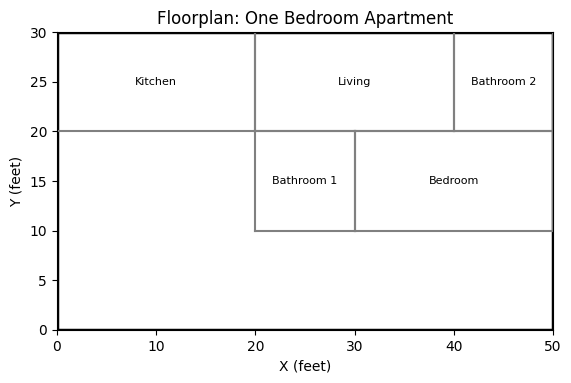

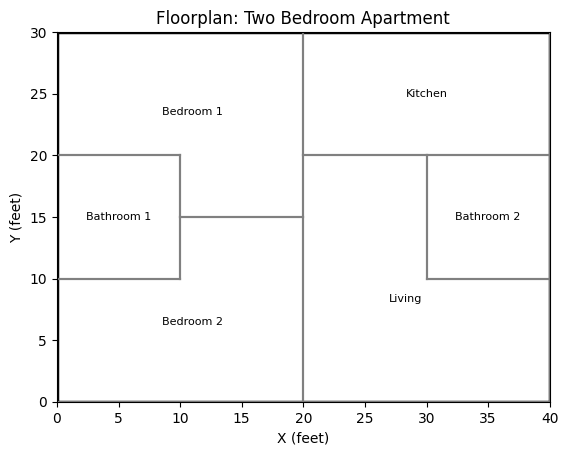


Note that floorplan 6 has a courtyard


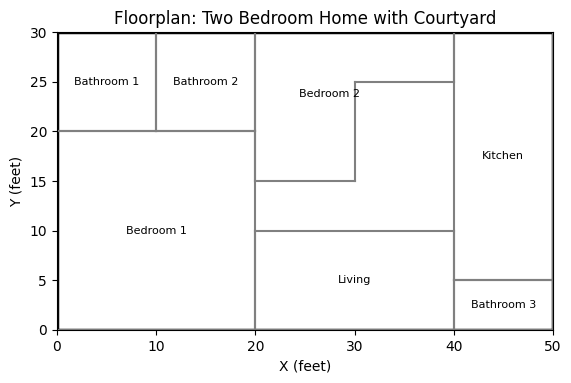

In [3]:
plot_floorplan(floorplan_1)
print("")
plot_floorplan(floorplan_3)
print("")
print("Note that floorplan 6 has a courtyard")
plot_floorplan(floorplan_6)

## Door Placement Algorithm

The solution below treats door placement as a deterministic geometry and graph problem. First, it finds room pairs that share a collinear wall segment with enough overlap for a door. Those overlaps become candidate graph edges. Each edge is scored using simple architectural preferences: public/circulation links are preferred, bedroom and bathroom access is allowed, and awkward connections such as bathroom-to-bathroom or kitchen-to-bathroom are only used when needed for connectivity.

The final door set is selected with a Kruskal-style pass over the scored candidates. The first pass keeps bathrooms as leaf spaces when possible; a second pass relaxes that privacy rule only if it is required to make all rooms reachable. Doors are centered on the chosen wall overlap, kept away from corners when there is room, and adaptively shortened for small shared walls.

Assumptions: room walls are orthogonal line segments, room boundaries meet exactly or within a tiny floating point tolerance, and the right output is a coherent connected room graph rather than every possible shared-wall opening.

90%+ of the code itself is written by AI (codex), however the algorithmic choices as well as choosing to make it deterministic with no ML, and most of the scoring algorithm were my decisions. The exact algorithm to select the door set was chosen by AI after some discussion on the most optimal one for this specific problem.


In [4]:
from dataclasses import dataclass
from itertools import combinations
from math import isclose

EPS = 1e-6
DEFAULT_DOOR_WIDTH = 3.0
MIN_DOOR_WIDTH = 2.25
END_CLEARANCE = 0.75
BATHROOM_SOFT_DOOR_CAP = 1

PUBLIC_TYPES = {"living", "kitchen", "dining", "entry", "foyer", "hall", "hallway", "corridor"}
CIRCULATION_TYPES = {"living", "entry", "foyer", "hall", "hallway", "corridor"}
PRIVATE_TYPES = {"bedroom", "primary_bedroom", "office", "study", "den"}
SERVICE_TYPES = {"bathroom", "powder", "closet", "laundry", "utility", "storage"}


@dataclass(frozen=True)
class NormalizedWall:
    orientation: str
    constant: float
    low: float
    high: float
    wall: dict


@dataclass(frozen=True)
class DoorCandidate:
    room_a: str
    room_b: str
    type_a: str
    type_b: str
    orientation: str
    constant: float
    low: float
    high: float
    length: float
    score: float


def _room_type(room):
    return (room.get("type") or room.get("name") or "unknown").strip().lower().replace(" ", "_")


def _point_xy(point):
    return float(point["x"]), float(point["y"])


def normalize_wall(wall, tol=EPS):
    """Return an axis-aligned normalized segment, or None for unsupported walls."""
    x1, y1 = _point_xy(wall["start"])
    x2, y2 = _point_xy(wall["end"])

    if abs(x1 - x2) <= tol:
        return NormalizedWall("vertical", x1, min(y1, y2), max(y1, y2), wall)
    if abs(y1 - y2) <= tol:
        return NormalizedWall("horizontal", y1, min(x1, x2), max(x1, x2), wall)
    return None


def shared_wall_overlap(wall_a, wall_b, min_width=MIN_DOOR_WIDTH, tol=EPS):
    """Find the shared interval between two normalized room walls."""
    a = normalize_wall(wall_a, tol)
    b = normalize_wall(wall_b, tol)
    if a is None or b is None:
        return None
    if a.orientation != b.orientation:
        return None
    if abs(a.constant - b.constant) > tol:
        return None

    low = max(a.low, b.low)
    high = min(a.high, b.high)
    length = high - low
    if length + tol < min_width:
        return None

    return {
        "orientation": a.orientation,
        "constant": (a.constant + b.constant) / 2.0,
        "low": low,
        "high": high,
        "length": length,
    }


def is_public(room_type):
    return room_type in PUBLIC_TYPES


def is_circulation(room_type):
    return room_type in CIRCULATION_TYPES


def is_private(room_type):
    return room_type in PRIVATE_TYPES


def is_service(room_type):
    return room_type in SERVICE_TYPES


def is_bathroom(room_type):
    return "bath" in room_type or room_type == "powder"


def connection_score(type_a, type_b, shared_length):
    """Higher scores represent more natural architectural connections."""
    types = {type_a, type_b}
    score = 10.0 + min(shared_length, 12.0) * 0.75

    if types & {"hall", "hallway", "corridor", "entry", "foyer"}:
        score += 80

    if is_public(type_a) and is_public(type_b):
        score += 65
    if {"living", "kitchen"} <= types or {"living", "dining"} <= types:
        score += 25

    if (is_circulation(type_a) and is_private(type_b)) or (is_circulation(type_b) and is_private(type_a)):
        score += 50
    elif (is_public(type_a) and is_private(type_b)) or (is_public(type_b) and is_private(type_a)):
        score += 8
    if (is_circulation(type_a) and is_service(type_b)) or (is_circulation(type_b) and is_service(type_a)):
        score += 42
    elif (is_public(type_a) and is_service(type_b)) or (is_public(type_b) and is_service(type_a)):
        score += 8
    if (is_bathroom(type_a) and is_private(type_b)) or (is_bathroom(type_b) and is_private(type_a)):
        score += 32

    if is_bathroom(type_a) and is_bathroom(type_b):
        score -= 85
    if "kitchen" in types and any(is_private(t) for t in types):
        score -= 18
    if {"kitchen", "bathroom"} <= types or ("kitchen" in types and any(is_bathroom(t) for t in types)):
        score -= 55
    if is_private(type_a) and is_private(type_b):
        score -= 18
    if is_service(type_a) and is_service(type_b) and not ({type_a, type_b} & {"hall", "hallway", "corridor"}):
        score -= 30

    return score


def find_door_candidates(floorplan):
    """Build all possible room-to-room door candidates from shared walls."""
    candidates = []
    rooms = floorplan["rooms"]

    for room_a, room_b in combinations(rooms, 2):
        type_a = _room_type(room_a)
        type_b = _room_type(room_b)
        for wall_a in room_a["walls"]:
            for wall_b in room_b["walls"]:
                overlap = shared_wall_overlap(wall_a, wall_b)
                if overlap is None:
                    continue
                candidates.append(
                    DoorCandidate(
                        room_a=room_a["id"],
                        room_b=room_b["id"],
                        type_a=type_a,
                        type_b=type_b,
                        orientation=overlap["orientation"],
                        constant=overlap["constant"],
                        low=overlap["low"],
                        high=overlap["high"],
                        length=overlap["length"],
                        score=connection_score(type_a, type_b, overlap["length"]),
                    )
                )

    return candidates


class DisjointSet:
    def __init__(self, items):
        self.parent = {item: item for item in items}
        self.rank = {item: 0 for item in items}

    def find(self, item):
        if self.parent[item] != item:
            self.parent[item] = self.find(self.parent[item])
        return self.parent[item]

    def union(self, left, right):
        root_left = self.find(left)
        root_right = self.find(right)
        if root_left == root_right:
            return False
        if self.rank[root_left] < self.rank[root_right]:
            root_left, root_right = root_right, root_left
        self.parent[root_right] = root_left
        if self.rank[root_left] == self.rank[root_right]:
            self.rank[root_left] += 1
        return True

    def component_count(self):
        return len({self.find(item) for item in self.parent})


def choose_connections(floorplan, candidates):
    """Choose a connected set of candidate doors, preserving bathroom privacy when possible."""
    room_ids = [room["id"] for room in floorplan["rooms"]]
    room_types = {room["id"]: _room_type(room) for room in floorplan["rooms"]}
    ordered = sorted(candidates, key=lambda c: (c.score, c.length), reverse=True)

    dsu = DisjointSet(room_ids)
    selected = []
    degree = {room_id: 0 for room_id in room_ids}

    def bathroom_cap_would_be_exceeded(candidate):
        for room_id in (candidate.room_a, candidate.room_b):
            if is_bathroom(room_types[room_id]) and degree[room_id] >= BATHROOM_SOFT_DOOR_CAP:
                return True
        return False

    # First pass: prefer high-scoring edges and keep bathrooms as leaves.
    for candidate in ordered:
        if dsu.find(candidate.room_a) == dsu.find(candidate.room_b):
            continue
        if bathroom_cap_would_be_exceeded(candidate):
            continue
        if dsu.union(candidate.room_a, candidate.room_b):
            selected.append(candidate)
            degree[candidate.room_a] += 1
            degree[candidate.room_b] += 1

    # Second pass: relax bathroom cap if it is the only way to connect all rooms.
    for candidate in ordered:
        if dsu.component_count() == 1:
            break
        if dsu.union(candidate.room_a, candidate.room_b):
            selected.append(candidate)
            degree[candidate.room_a] += 1
            degree[candidate.room_b] += 1

    unreachable_components = dsu.component_count()
    return selected, unreachable_components


def opening_kind(candidate):
    """Use archways only for public-public transitions; everything else is a door."""
    if is_public(candidate.type_a) and is_public(candidate.type_b):
        return "archway"
    return "door"


def swing_target(candidate):
    """Simple optional swing metadata: bathroom doors swing into bathrooms first."""
    rooms = ((candidate.room_a, candidate.type_a), (candidate.room_b, candidate.type_b))
    for room_id, room_type in rooms:
        if is_bathroom(room_type):
            return room_id
    for room_id, room_type in rooms:
        if is_private(room_type) or room_type in {"closet", "laundry", "utility"}:
            return room_id
    return candidate.room_b


def door_segment_for_candidate(candidate):
    """Place a door centered on the selected shared wall interval."""
    clearance = min(END_CLEARANCE, max(0.0, (candidate.length - MIN_DOOR_WIDTH) / 2.0))
    usable_low = candidate.low + clearance
    usable_high = candidate.high - clearance
    usable_length = usable_high - usable_low

    if usable_length + EPS < MIN_DOOR_WIDTH:
        usable_low = candidate.low
        usable_high = candidate.high
        usable_length = candidate.length

    width = min(DEFAULT_DOOR_WIDTH, usable_length)
    if width + EPS < MIN_DOOR_WIDTH:
        return None

    center = (usable_low + usable_high) / 2.0
    start_axis = center - width / 2.0
    end_axis = center + width / 2.0

    if candidate.orientation == "vertical":
        start = {"x": candidate.constant, "y": start_axis}
        end = {"x": candidate.constant, "y": end_axis}
    else:
        start = {"x": start_axis, "y": candidate.constant}
        end = {"x": end_axis, "y": candidate.constant}

    return start, end, width


def generate_door_plan(floorplan):
    """Return placed doors plus lightweight diagnostics for a floorplan."""
    candidates = find_door_candidates(floorplan)
    selected, component_count = choose_connections(floorplan, candidates)

    doors = []
    for index, candidate in enumerate(selected, start=1):
        segment = door_segment_for_candidate(candidate)
        if segment is None:
            continue
        start, end, width = segment
        doors.append(
            {
                "id": f"door_{index}",
                "between": [candidate.room_a, candidate.room_b],
                "kind": opening_kind(candidate),
                "start": start,
                "end": end,
                "width": round(width, 3),
                "orientation": candidate.orientation,
                "score": round(candidate.score, 3),
                "swing_into": None if opening_kind(candidate) == "archway" else swing_target(candidate),
            }
        )

    diagnostics = {
        "candidate_count": len(candidates),
        "selected_count": len(selected),
        "door_count": len(doors),
        "connected": component_count == 1 if floorplan["rooms"] else True,
        "component_count": component_count,
    }
    return doors, diagnostics


In [5]:
def plot_floorplan_with_doors(floorplan, doors):
    plt.figure(figsize=(8, 5))

    for wall in floorplan["exteriorWalls"]:
        x_values = [wall["start"]["x"], wall["end"]["x"]]
        y_values = [wall["start"]["y"], wall["end"]["y"]]
        plt.plot(x_values, y_values, color="black", linewidth=wall["thickness"] * 5)

    for room in floorplan["rooms"]:
        for wall in room["walls"]:
            x_values = [wall["start"]["x"], wall["end"]["x"]]
            y_values = [wall["start"]["y"], wall["end"]["y"]]
            plt.plot(x_values, y_values, color="lightgray", linewidth=wall["thickness"] * 5)

    for door in doors:
        x_values = [door["start"]["x"], door["end"]["x"]]
        y_values = [door["start"]["y"], door["end"]["y"]]
        color = "tab:orange" if door["kind"] == "door" else "tab:green"
        plt.plot(x_values, y_values, color=color, linewidth=6, solid_capstyle="butt")
        label_x = (x_values[0] + x_values[1]) / 2.0
        label_y = (y_values[0] + y_values[1]) / 2.0
        plt.text(label_x, label_y, door["id"], ha="center", va="center", fontsize=7, color="black")

    for room in floorplan["rooms"]:
        vertices = [wall["start"] for wall in room["walls"]]
        if room["walls"]:
            vertices.append(room["walls"][-1]["end"])
        centroid = calculate_polygon_centroid(vertices)
        if centroid:
            plt.text(centroid[0], centroid[1], room["name"], ha="center", va="center", fontsize=8)

    plt.xlim(0, floorplan["dimensions"]["width"])
    plt.ylim(0, floorplan["dimensions"]["height"])
    plt.gca().set_aspect("equal", adjustable="box")
    plt.title(f"Door plan: {floorplan['name']}")
    plt.xlabel("X (feet)")
    plt.ylabel("Y (feet)")
    plt.show()


def print_door_summary(floorplan, doors, diagnostics):
    print(f"{floorplan['name']} ({floorplan['id']})")
    print(f"  candidates: {diagnostics['candidate_count']}")
    print(f"  selected openings: {diagnostics['door_count']}")
    print(f"  connected: {diagnostics['connected']} (components: {diagnostics['component_count']})")
    for door in doors:
        start = door["start"]
        end = door["end"]
        print(
            f"  {door['id']}: {door['kind']} between {door['between'][0]} and {door['between'][1]} "
            f"from ({start['x']:.2f}, {start['y']:.2f}) to ({end['x']:.2f}, {end['y']:.2f}), "
            f"width {door['width']:.2f} ft"
        )
    print()


One Bedroom Apartment (1)
  candidates: 6
  selected openings: 4
  connected: True (components: 1)
  door_1: archway between kitchen and living from (20.00, 23.50) to (20.00, 26.50), width 3.00 ft
  door_2: door between living and bedroom from (33.50, 20.00) to (36.50, 20.00), width 3.00 ft
  door_3: door between living and bathroom_1 from (23.50, 20.00) to (26.50, 20.00), width 3.00 ft
  door_4: door between living and bathroom_2 from (40.00, 23.50) to (40.00, 26.50), width 3.00 ft



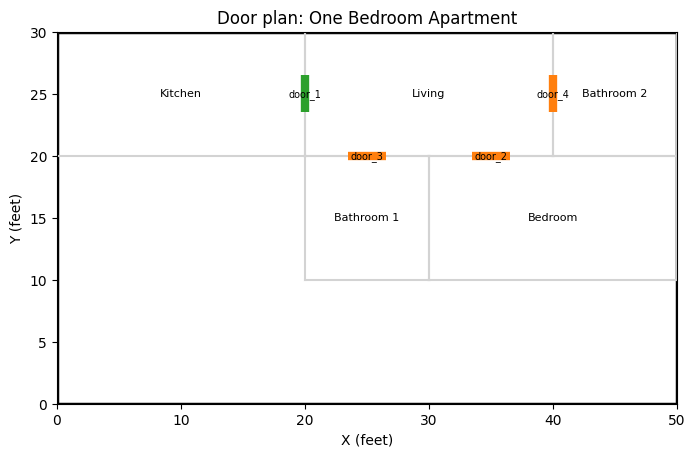

Two Bedroom Apartment (3)
  candidates: 12
  selected openings: 5
  connected: True (components: 1)
  door_1: archway between kitchen and living from (23.50, 20.00) to (26.50, 20.00), width 3.00 ft
  door_2: door between bedroom_2 and living from (20.00, 6.00) to (20.00, 9.00), width 3.00 ft
  door_3: door between bedroom_1 and living from (20.00, 16.00) to (20.00, 19.00), width 3.00 ft
  door_4: door between bathroom_2 and living from (33.50, 10.00) to (36.50, 10.00), width 3.00 ft
  door_5: door between bedroom_1 and bathroom_1 from (3.50, 20.00) to (6.50, 20.00), width 3.00 ft



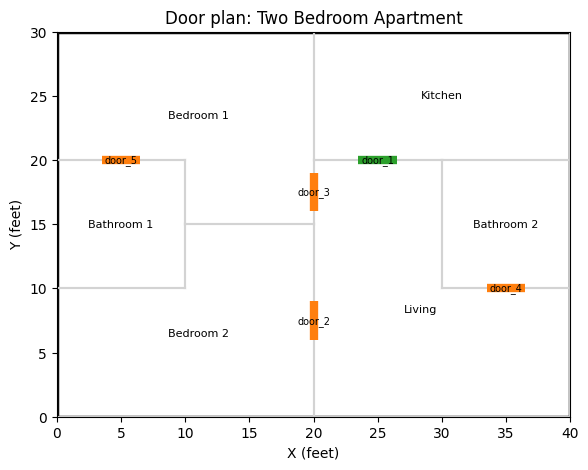

Two Bedroom Home with Courtyard (6)
  candidates: 10
  selected openings: 6
  connected: True (components: 1)
  door_1: archway between living and kitchen from (40.00, 6.00) to (40.00, 9.00), width 3.00 ft
  door_2: door between bedroom_1 and living from (20.00, 3.50) to (20.00, 6.50), width 3.00 ft
  door_3: door between living and bathroom_3 from (40.00, 1.00) to (40.00, 4.00), width 3.00 ft
  door_4: door between bathroom_1 and bedroom_1 from (3.50, 20.00) to (6.50, 20.00), width 3.00 ft
  door_5: door between bathroom_2 and bedroom_1 from (13.50, 20.00) to (16.50, 20.00), width 3.00 ft
  door_6: door between bedroom_2 and kitchen from (40.00, 26.00) to (40.00, 29.00), width 3.00 ft



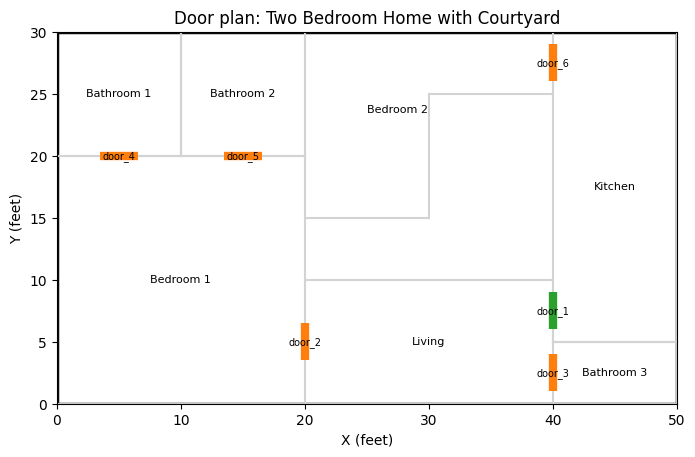

In [6]:
floorplans = [floorplan_1, floorplan_3, floorplan_6]
all_door_plans = {}

for floorplan in floorplans:
    doors, diagnostics = generate_door_plan(floorplan)
    all_door_plans[floorplan["id"]] = {"doors": doors, "diagnostics": diagnostics}
    print_door_summary(floorplan, doors, diagnostics)
    plot_floorplan_with_doors(floorplan, doors)
